In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings(action='ignore')

In [2]:
df=pd.read_csv(r'/Users/rajeshwarisowdasoth/Downloads/Titanic-Dataset.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Data EDA

In [4]:
df.shape

(891, 12)

In [5]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Data Cleaning

In [8]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
df=df.drop('Cabin',axis=1)

In [10]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

In [11]:
df['Age'].skew()

np.float64(0.38910778230082704)

In [12]:
df['Age']=df['Age'].fillna(df['Age'].mean())

In [13]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [14]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

In [15]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### Duplicate

In [16]:
print(df.duplicated().sum())

0


### Outlier Analysis

In [17]:
a=df.select_dtypes(include=np.number)

<Axes: >

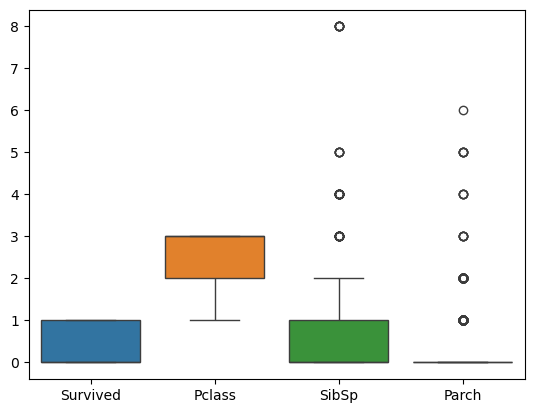

In [18]:
sns.boxplot([df['Survived'],df['Pclass'],df['SibSp'],df['Parch']])

### IQR

In [19]:
for i in a:
    q1=a[i].quantile(0.25)
    q2=a[i].quantile(0.50)
    q3=a[i].quantile(0.75)

In [20]:
IQR=q3-q1

In [21]:
Uw=q3+1.5*IQR
Lw=q1-1.5*IQR

In [22]:
outliers=((a[i]>Uw)|(a[i]<Lw))

In [23]:
print(outliers.sum())

116


In [24]:
a.loc[(a[i]>Uw)|(a[i]<Lw),i]=q2

In [25]:
print(outliers.sum())

116


# DATA ANALYSIS

In [26]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [27]:
print(df['PassengerId'].count())

891


### Most of the people died in the incident

In [28]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

### Female survived more in the incident

In [29]:
df.groupby('Sex')['Survived'].mean()*100

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

### Binning

### Passengers from the class 1 survived more

In [30]:
bins=[0,18,40,70]
labels=['child','adult','old']
df['AgeGroup']=pd.cut(df['Age'],bins=bins,labels=labels)

In [31]:
c=df.groupby('AgeGroup')['Survived'].mean()*100

### Child survived more in the incident

In [32]:
d=df.groupby('Pclass')['Survived'].mean()*100

### The customers who are paying the more, surviving the more

In [33]:
df.sort_values(by='Fare',ascending=False).head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,AgeGroup
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,C,adult
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,C,adult
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,C,adult
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,S,adult
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,S,adult


# DATA VISULALISATION & DASHBOARD

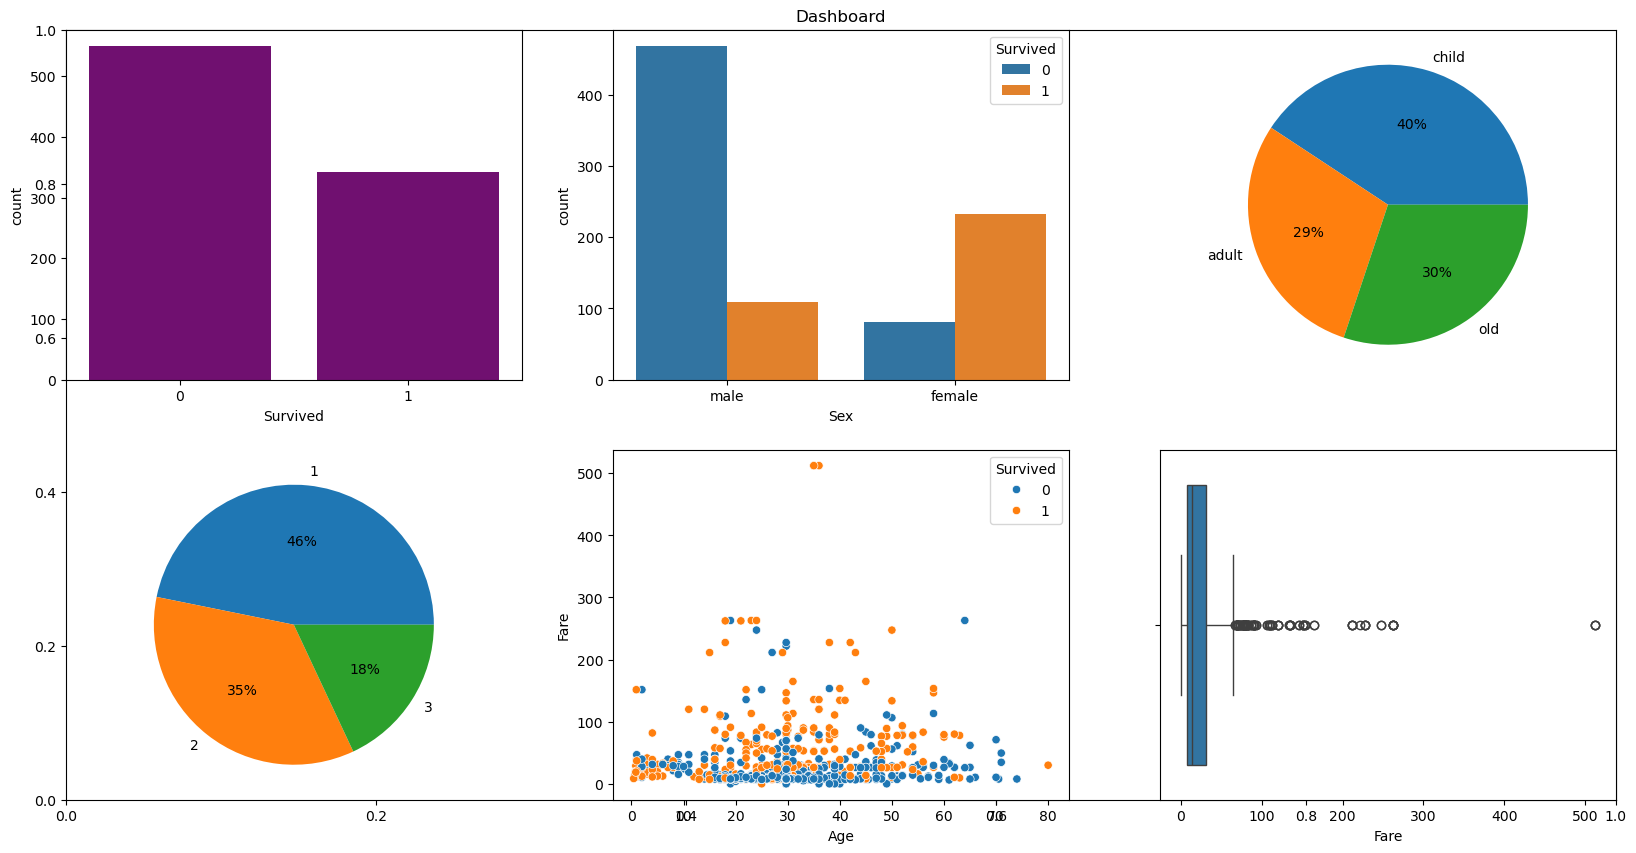

In [34]:
plt.figure(figsize=(20,10))
plt.title('Dashboard')
plt.subplot(2,3,1)
sns.countplot(x='Survived',data=df,color='purple')

plt.subplot(2,3,2)
sns.countplot(x='Sex',hue='Survived',data=df)

plt.subplot(2,3,3)
plt.pie(c.values,labels=c.index,autopct='%1d%%')

plt.subplot(2,3,4)
plt.pie(d.values,labels=d.index,autopct='%1d%%')

plt.subplot(2,3,5)
sns.scatterplot(x='Age',y='Fare',hue='Survived',data=df)

plt.subplot(2,3,6)
sns.boxplot(x='Fare',data=df)
plt.show()

# DATA STORY TELLING